In [1]:
import pandas as pd

df = pd.read_csv("Global_Superstore.csv", encoding="latin1")

EDA Section 1: Dataset Overview
Questions:

How many rows?
How many columns?
Numeric vs categorical columns?

In [2]:
print(df.shape)

df.info()

df.describe()

(51290, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    512

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


EDA Section 2: Missing Values

In [3]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [4]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

Postal Code       80.51472
Row ID             0.00000
Region             0.00000
Shipping Cost      0.00000
Profit             0.00000
Discount           0.00000
Quantity           0.00000
Sales              0.00000
Product Name       0.00000
Sub-Category       0.00000
Category           0.00000
Product ID         0.00000
Market             0.00000
Order ID           0.00000
Country            0.00000
State              0.00000
City               0.00000
Segment            0.00000
Customer Name      0.00000
Customer ID        0.00000
Ship Mode          0.00000
Ship Date          0.00000
Order Date         0.00000
Order Priority     0.00000
dtype: float64

In [5]:
df = df.drop(columns=["Postal Code"])

EDA Section 3: Duplicate Records

In [6]:
df.duplicated().sum()

np.int64(0)

EDA Section 4: Sales Distribution
Questions:

Is sales normally distributed?
Are there outliers?

In [7]:
df["Sales"].describe()

count    51290.000000
mean       246.490581
std        487.565361
min          0.444000
25%         30.758625
50%         85.053000
75%        251.053200
max      22638.480000
Name: Sales, dtype: float64

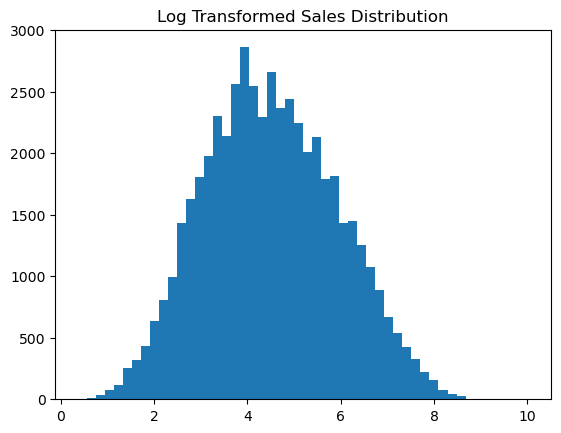

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(np.log1p(df["Sales"]), bins=50)
plt.title("Log Transformed Sales Distribution")
plt.show()

EDA Section 5: Profit Distribution
Questions:

How many negative-profit transactions?

In [9]:
df["Profit"].describe()

count    51290.000000
mean        28.610982
std        174.340972
min      -6599.978000
25%          0.000000
50%          9.240000
75%         36.810000
max       8399.976000
Name: Profit, dtype: float64

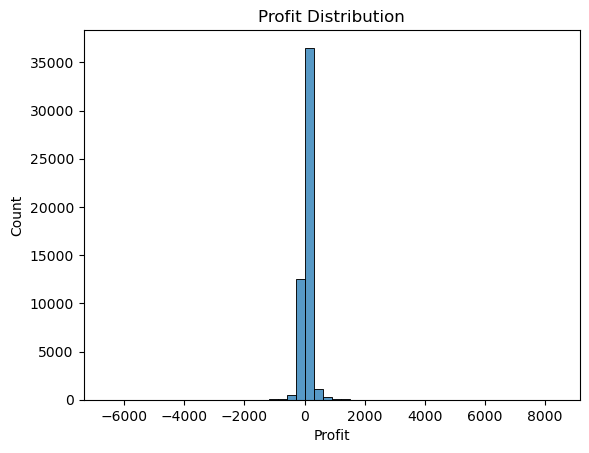

In [45]:
sns.histplot(df["Profit"], bins=50)
plt.title("Profit Distribution")
plt.show()

In [11]:
(df["Profit"] < 0).sum()

np.int64(12544)

In [12]:
(df["Profit"] < 0).mean()*100

np.float64(24.457009163579645)

EDA Section 6: Category Sales
Business question:

Which products and countries generate losses?

In [13]:
loss_orders = df[df["Profit"] < 0]

print(loss_orders.shape)

(12544, 23)


In [14]:
loss_orders["Profit"].sum()

np.float64(-920646.1557199999)

Section 07: Sub-Category Sales

In [15]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

subcategory_profit.head(10)

Sub-Category
Tables        -64083.3887
Fasteners      11525.4241
Labels         15010.5120
Supplies       22583.2631
Envelopes      29601.1163
Furnishings    46967.4255
Art            57953.9109
Machines       58867.8730
Paper          59207.6827
Binders        72449.8460
Name: Profit, dtype: float64

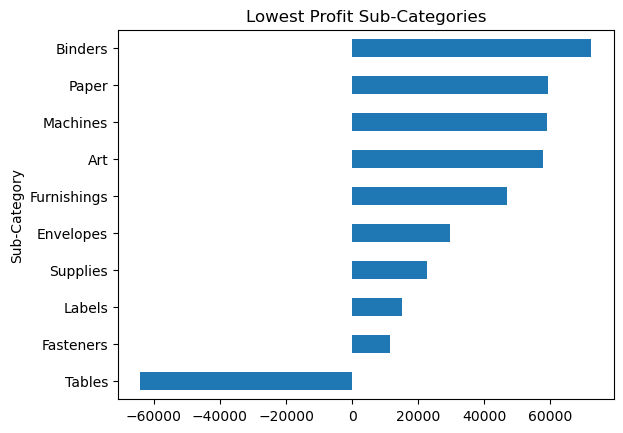

In [16]:
subcategory_profit.head(10).plot(kind="barh")
plt.title("Lowest Profit Sub-Categories")
plt.show()

Section 08: Regional Sales

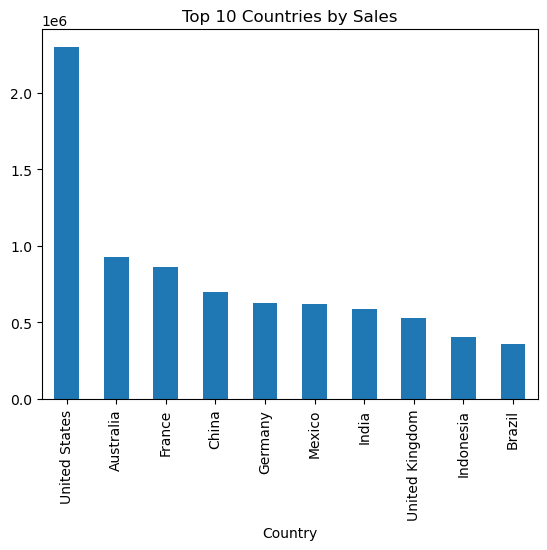

In [17]:
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.show()

Section 09: Market Sales

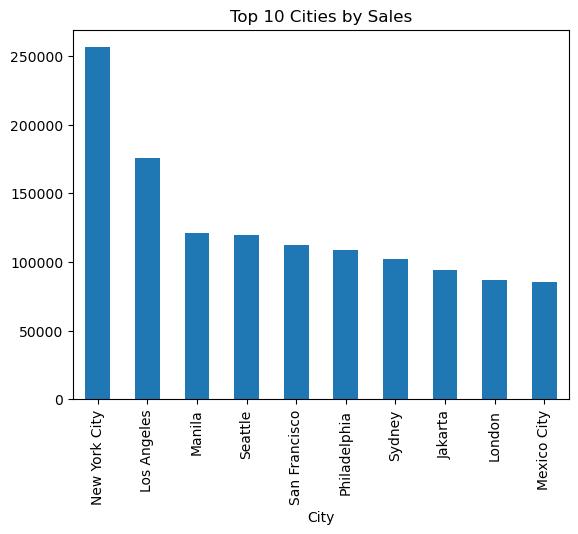

In [18]:
city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

city_sales.plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.show()

In [46]:
country_profit = (
    df.groupby("Country")["Profit"]
      .sum()
      .sort_values()
)

country_profit.head(10)

Country
Turkey        -98447.23200
Nigeria       -80750.71800
Netherlands   -41070.07500
Honduras      -29482.37140
Pakistan      -22446.64800
Argentina     -18693.79672
Panama        -17723.45248
Sweden        -17519.36700
Philippines   -16128.22500
South Korea   -12792.83100
Name: Profit, dtype: float64

Section 10:Discount vs Profit

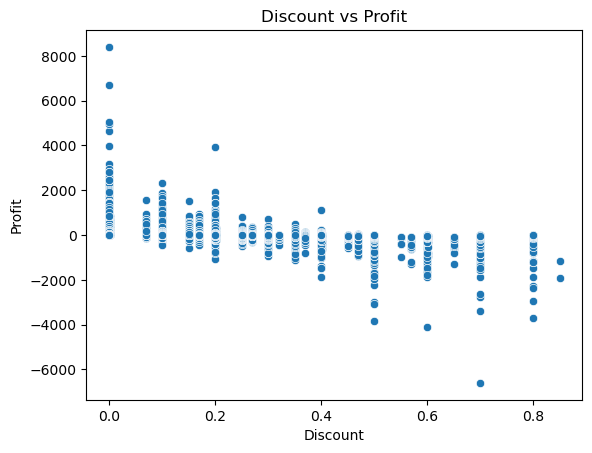

In [19]:
sns.scatterplot(
    x="Discount",
    y="Profit",
    data=df
)

plt.title("Discount vs Profit")
plt.show()

Section 11: Correlation Heatmap

In [20]:
df[["Sales","Quantity","Discount","Profit","Shipping Cost"]].corr()

,Sales,Quantity,Discount,Profit,Shipping Cost
Sales,1.000000,0.313577,-0.086722,0.484918,0.768073
Quantity,0.313577,1.000000,-0.019875,0.104365,0.272649
Discount,-0.086722,-0.019875,1.000000,-0.316490,-0.079056
Profit,0.484918,0.104365,-0.316490,1.000000,0.354441
Shipping Cost,0.768073,0.272649,-0.079056,0.354441,1.000000


<Axes: >

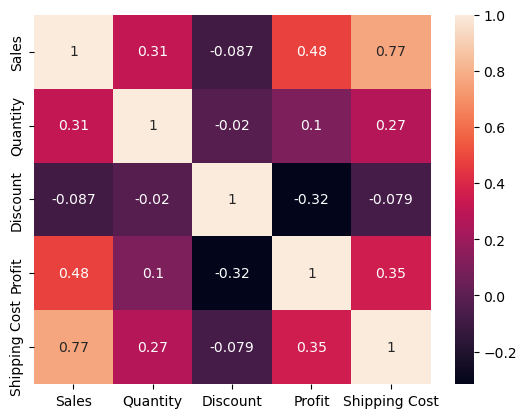

In [21]:
import seaborn as sns

sns.heatmap(
    df[["Sales","Quantity","Discount","Profit","Shipping Cost"]].corr(),
    annot=True
)

EDA Section 12: Category Analysis

In [22]:
df.groupby("Category")[["Sales","Profit"]].sum()

,Sales,Profit
Category,,
Furniture,4.110874e+06,285204.72380
Office Supplies,3.787070e+06,518473.83430
Technology,4.744557e+06,663778.73318


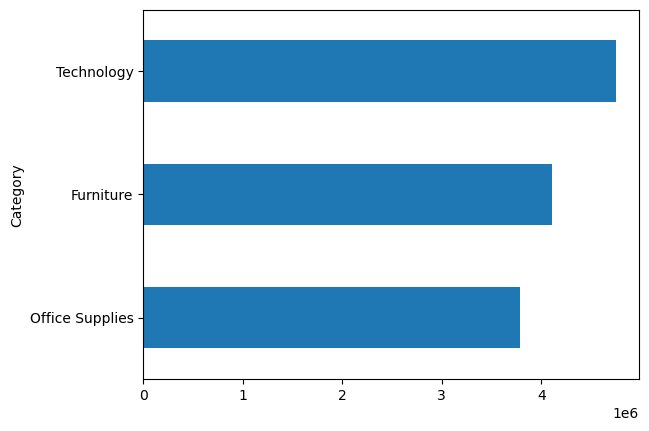

In [23]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values()
)

category_sales.plot(kind="barh")
plt.show()

Section 13: Time Series Analysis

In [24]:
print(df["Order Date"].head())
print(df["Ship Date"].head())

print(df["Order Date"].nunique())
print(df["Ship Date"].nunique())

0    31-07-2012
1    05-02-2013
2    17-10-2013
3    28-01-2013
4    05-11-2013
Name: Order Date, dtype: object
0    31-07-2012
1    07-02-2013
2    18-10-2013
3    30-01-2013
4    06-11-2013
Name: Ship Date, dtype: object
1430
1464


In [25]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y"
)

In [26]:
print(df["Order Date"].min())
print(df["Order Date"].max())

print(df["Ship Date"].min())
print(df["Ship Date"].max())

2011-01-01 00:00:00
2014-12-31 00:00:00
2011-01-03 00:00:00
2015-01-07 00:00:00


In [27]:
print(df["Order Date"].head(10).tolist())

[Timestamp('2012-07-31 00:00:00'), Timestamp('2013-02-05 00:00:00'), Timestamp('2013-10-17 00:00:00'), Timestamp('2013-01-28 00:00:00'), Timestamp('2013-11-05 00:00:00'), Timestamp('2013-06-28 00:00:00'), Timestamp('2011-11-07 00:00:00'), Timestamp('2012-04-14 00:00:00'), Timestamp('2014-10-14 00:00:00'), Timestamp('2012-01-28 00:00:00')]


In [28]:
print(df["Order Date"].isna().sum())
print(df["Ship Date"].isna().sum())

0
0


In [29]:
print(df["Order Date"].dt.year.value_counts().sort_index())

Order Date
2011     8998
2012    10962
2013    13799
2014    17531
Name: count, dtype: int64


In [30]:
print(df.shape)
print(df.columns.tolist())

(51290, 23)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


In [31]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
dtype: object

In [36]:
for col in ["Customer Name","City","State","Product Name"]:
    count = df[col].astype(str).apply(
        lambda x: any(ord(c) > 127 for c in x)
    ).sum()

    print(col, count)

Customer Name 416
City 2349
State 4255
Product Name 278


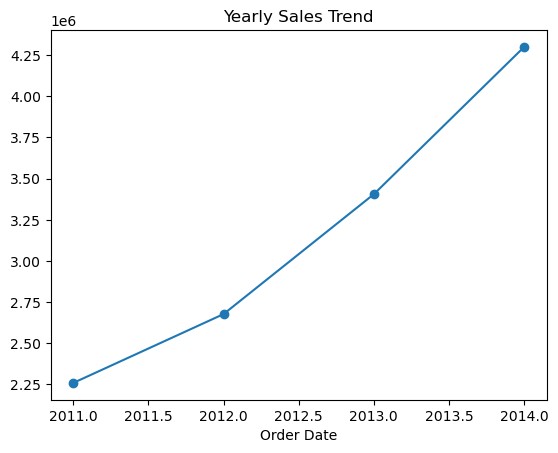

In [37]:
yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
)

yearly_sales.plot(marker="o")
plt.title("Yearly Sales Trend")
plt.show()

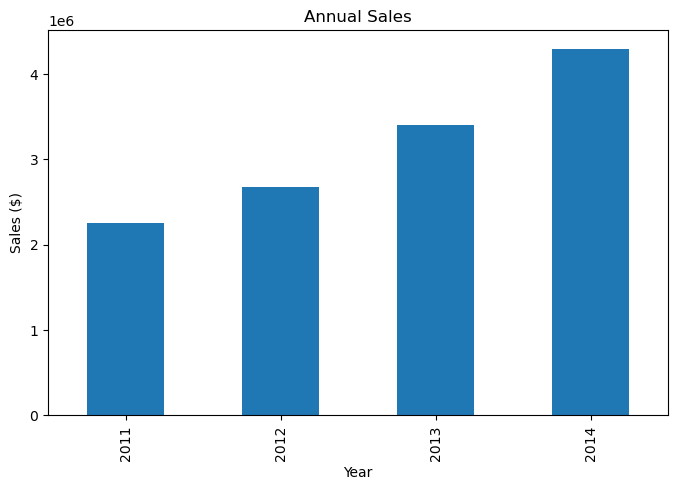

In [38]:
yearly_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Annual Sales")
plt.ylabel("Sales ($)")
plt.xlabel("Year")
plt.show()

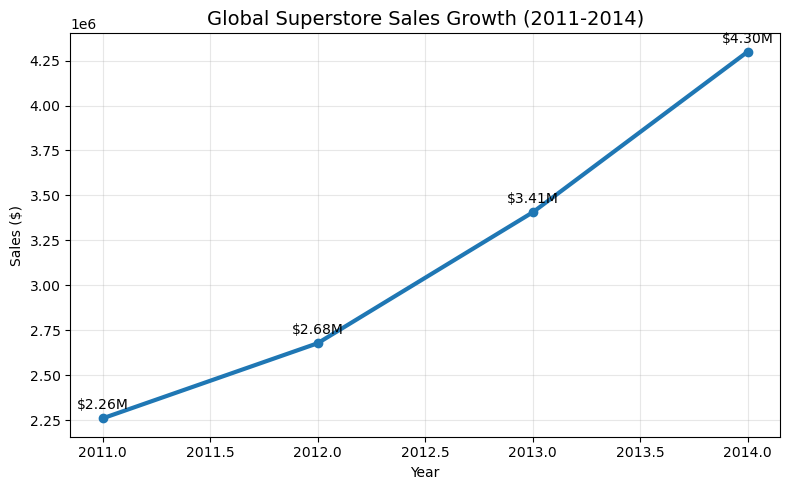

In [39]:
import matplotlib.pyplot as plt

yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    linewidth=3
)

# Add values on points
for x, y in zip(yearly_sales.index, yearly_sales.values):
    plt.text(
        x,
        y + 50000,
        f"${y/1e6:.2f}M",
        ha="center"
    )

plt.title("Global Superstore Sales Growth (2011-2014)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Section 14:Sales vs Profit by Category

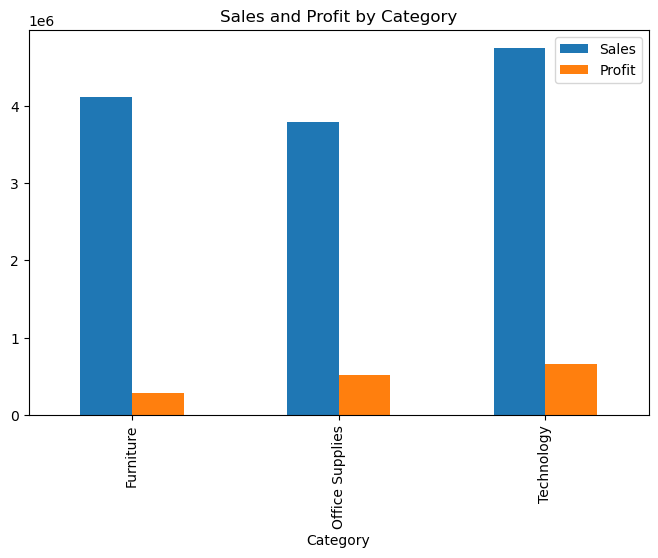

In [40]:
category_analysis = (
    df.groupby("Category")[["Sales","Profit"]]
      .sum()
)

category_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales and Profit by Category")
plt.show()

Section 15: Top 10 Sub-Categories by Sales

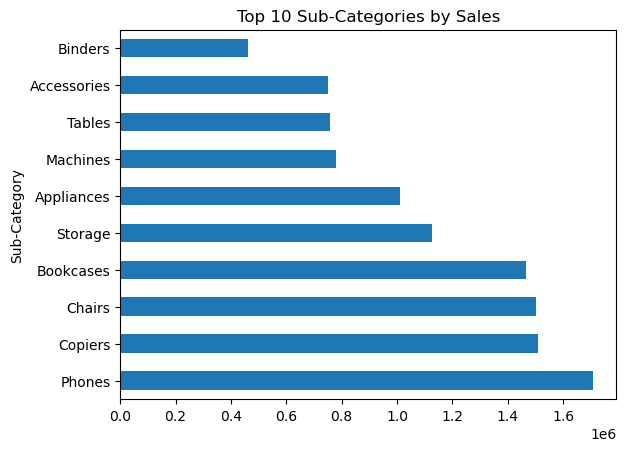

In [41]:
top_subcat = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_subcat.plot(kind="barh")
plt.title("Top 10 Sub-Categories by Sales")
plt.show()

Section 16:Shipping Analysis

In [42]:
df.groupby("Ship Mode")["Shipping Cost"].mean()

Ship Mode
First Class       41.053065
Same Day          42.937453
Second Class      30.469747
Standard Class    19.971755
Name: Shipping Cost, dtype: float64

<Axes: xlabel='Ship Mode', ylabel='Shipping Cost'>

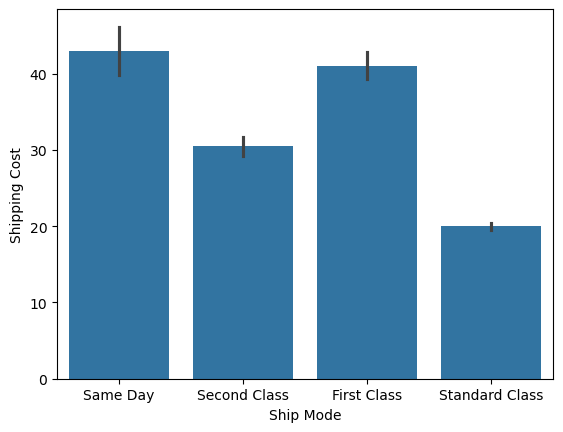

In [43]:
sns.barplot(
    data=df,
    x="Ship Mode",
    y="Shipping Cost"
)

In [47]:
df.to_csv(r"Global_Superstore_Final.csv",index=False,encoding="utf-8")